# Pipeline Metrics Visualization

This notebook visualizes the pipeline queue and channel sizes per shard during benchmark runs.

**Metrics visualized:**
- Queue Size (updateTaskQueues) - intermediate buffer before channels
- Channel Size (updateTaskChs) - buffered channel workers consume from

**What to look for:**
- High queue + full channel = Workers can't keep up
- Low queue + high channel = Pipeline flowing smoothly
- Growing queue over time = Backpressure building up

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

In [5]:
# === CONFIGURE THIS ===
PIPELINE_FILE = "../../benchmark_output/bench_pipeline_sizes_20260106_185029.csv"
WARMUP_SECONDS = 0
COOLDOWN_SECONDS = 0
# ======================

In [6]:
def load_pipeline_data(filepath, warmup_s, cooldown_s):
    """Load pipeline metrics and prepare for visualization."""
    df = pd.read_csv(filepath)
    
    # Convert timestamp
    df["timestamp_s"] = df["timestamp_ns"] / 1e9
    
    # Trim warmup/cooldown
    min_time = df["timestamp_s"].min()
    max_time = df["timestamp_s"].max()
    start_time = min_time + warmup_s
    end_time = max_time - cooldown_s
    
    df = df[(df["timestamp_s"] >= start_time) & (df["timestamp_s"] <= end_time)].copy()
    df["time_normalized"] = df["timestamp_s"] - start_time
    
    return df

# Load data
df = load_pipeline_data(PIPELINE_FILE, WARMUP_SECONDS, COOLDOWN_SECONDS)
print(f"Loaded {len(df)} samples")

# Get shard info
shard_ids = sorted(df["shard_id"].unique())
num_shards = len(shard_ids)
print(f"Found {num_shards} shards")

# Get channel capacity (constant)
channel_capacity = df["channel_capacity"].iloc[0] if len(df) > 0 else 0
print(f"Channel capacity: {channel_capacity}")

Loaded 96640 samples
Found 32 shards
Channel capacity: 1000


In [7]:
def aggregate_all_shards(df):
    """Aggregate metrics across all shards."""
    agg = df.groupby("timestamp_ns").agg({
        "time_normalized": "first",
        "queue_size": "sum",
        "channel_size": "sum",
        "channel_capacity": "sum",
    }).reset_index()
    return agg

df_agg = aggregate_all_shards(df)
print(f"Aggregated to {len(df_agg)} time points")

Aggregated to 3020 time points


---
## Aggregated Metrics (All Shards Combined)

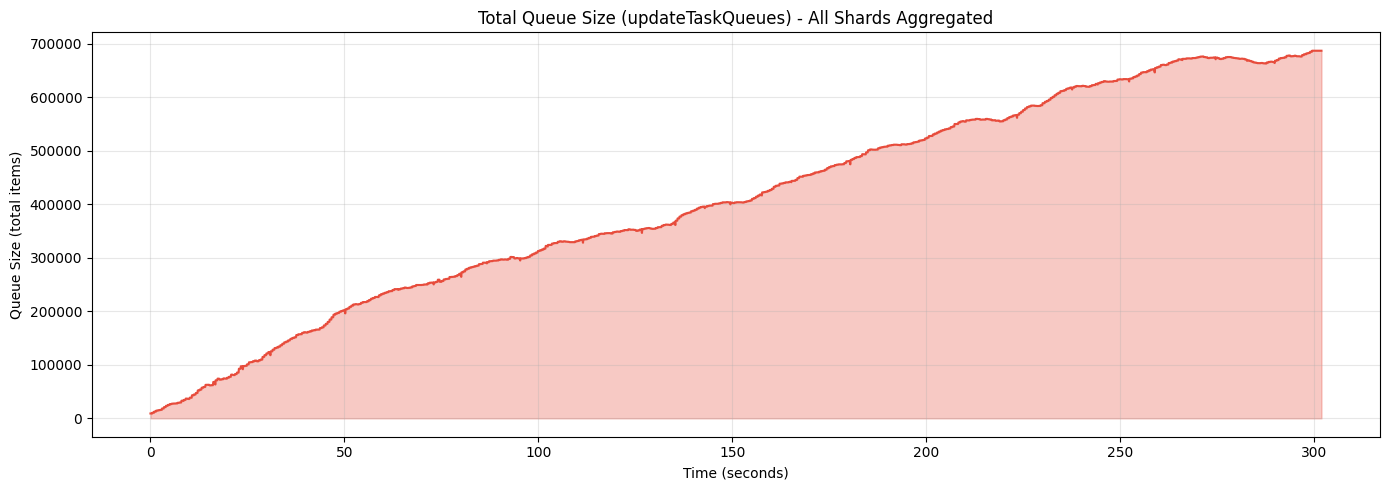

In [8]:
# Queue Size (Aggregated)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_agg["time_normalized"], df_agg["queue_size"], color="#e74c3c", linewidth=1.5)
ax.fill_between(df_agg["time_normalized"], df_agg["queue_size"], alpha=0.3, color="#e74c3c")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Queue Size (total items)")
ax.set_title("Total Queue Size (updateTaskQueues) - All Shards Aggregated")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

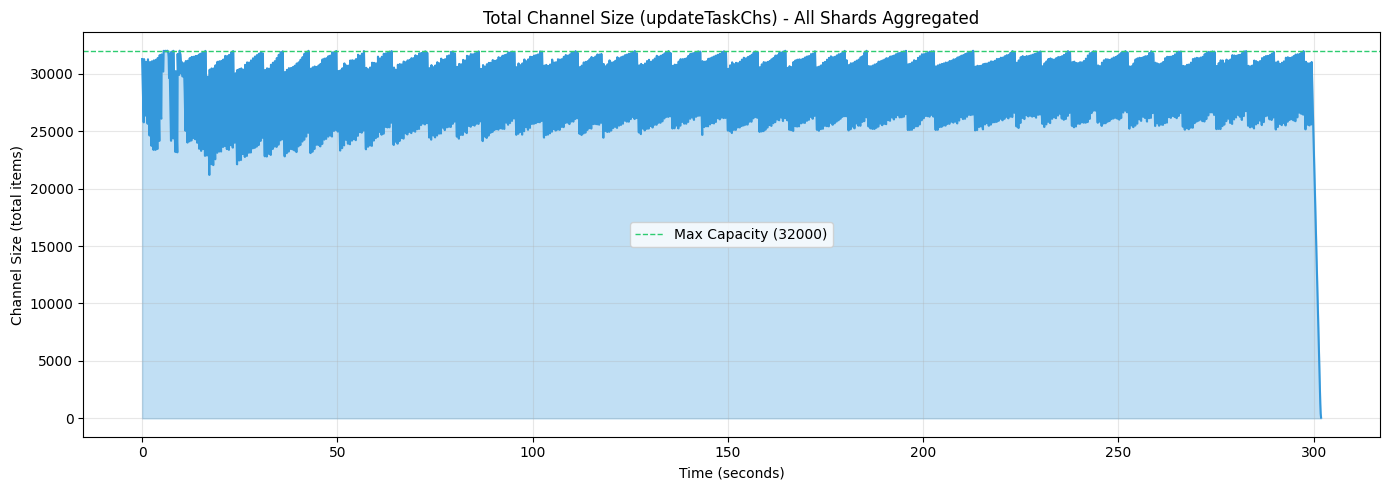

In [9]:
# Channel Size (Aggregated)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_agg["time_normalized"], df_agg["channel_size"], color="#3498db", linewidth=1.5)
ax.fill_between(df_agg["time_normalized"], df_agg["channel_size"], alpha=0.3, color="#3498db")
ax.axhline(y=df_agg["channel_capacity"].iloc[0], color="#2ecc71", linestyle="--", linewidth=1, label=f"Max Capacity ({df_agg['channel_capacity'].iloc[0]})")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Channel Size (total items)")
ax.set_title("Total Channel Size (updateTaskChs) - All Shards Aggregated")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

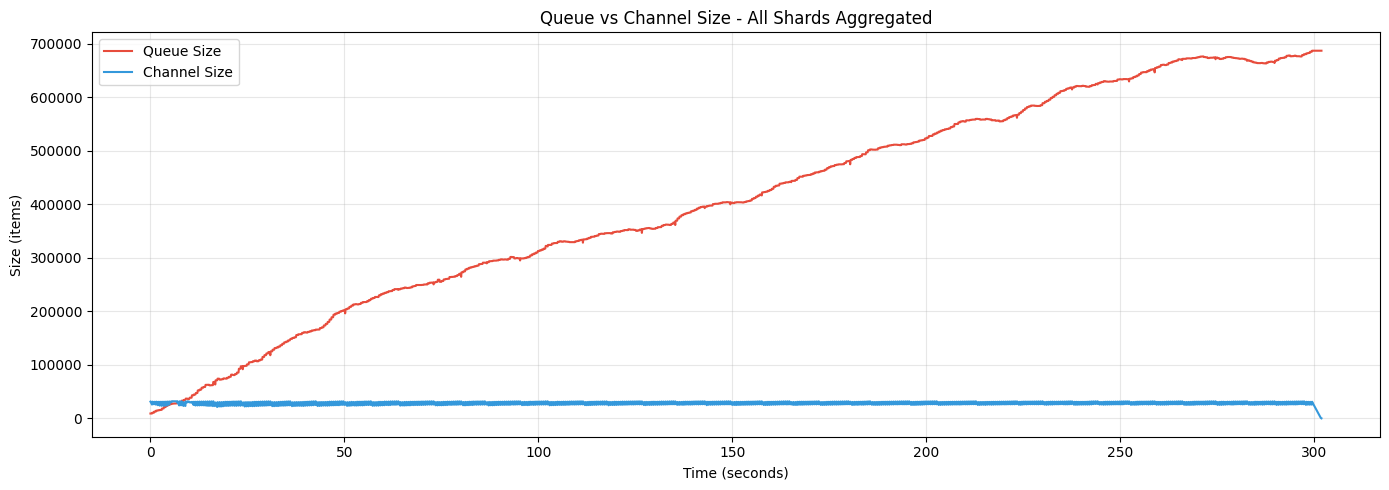

In [10]:
# Combined: Queue + Channel (Aggregated)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_agg["time_normalized"], df_agg["queue_size"], color="#e74c3c", linewidth=1.5, label="Queue Size")
ax.plot(df_agg["time_normalized"], df_agg["channel_size"], color="#3498db", linewidth=1.5, label="Channel Size")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Size (items)")
ax.set_title("Queue vs Channel Size - All Shards Aggregated")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Per-Shard Metrics (Individual Plots)

In [11]:
def plot_per_shard(df, shard_ids, metric_col, ylabel, title_prefix, color):
    """Plot a metric for each shard in a grid."""
    num_shards = len(shard_ids)
    cols = 4
    rows = (num_shards + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    fig.suptitle(f"{title_prefix} (Per Shard)", fontsize=14, fontweight="bold")
    
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for i, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        ax = axes[i]
        ax.plot(shard_df["time_normalized"], shard_df[metric_col], color=color, linewidth=1)
        ax.fill_between(shard_df["time_normalized"], shard_df[metric_col], alpha=0.3, color=color)
        ax.set_title(f"Shard {shard_id}", fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(num_shards, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

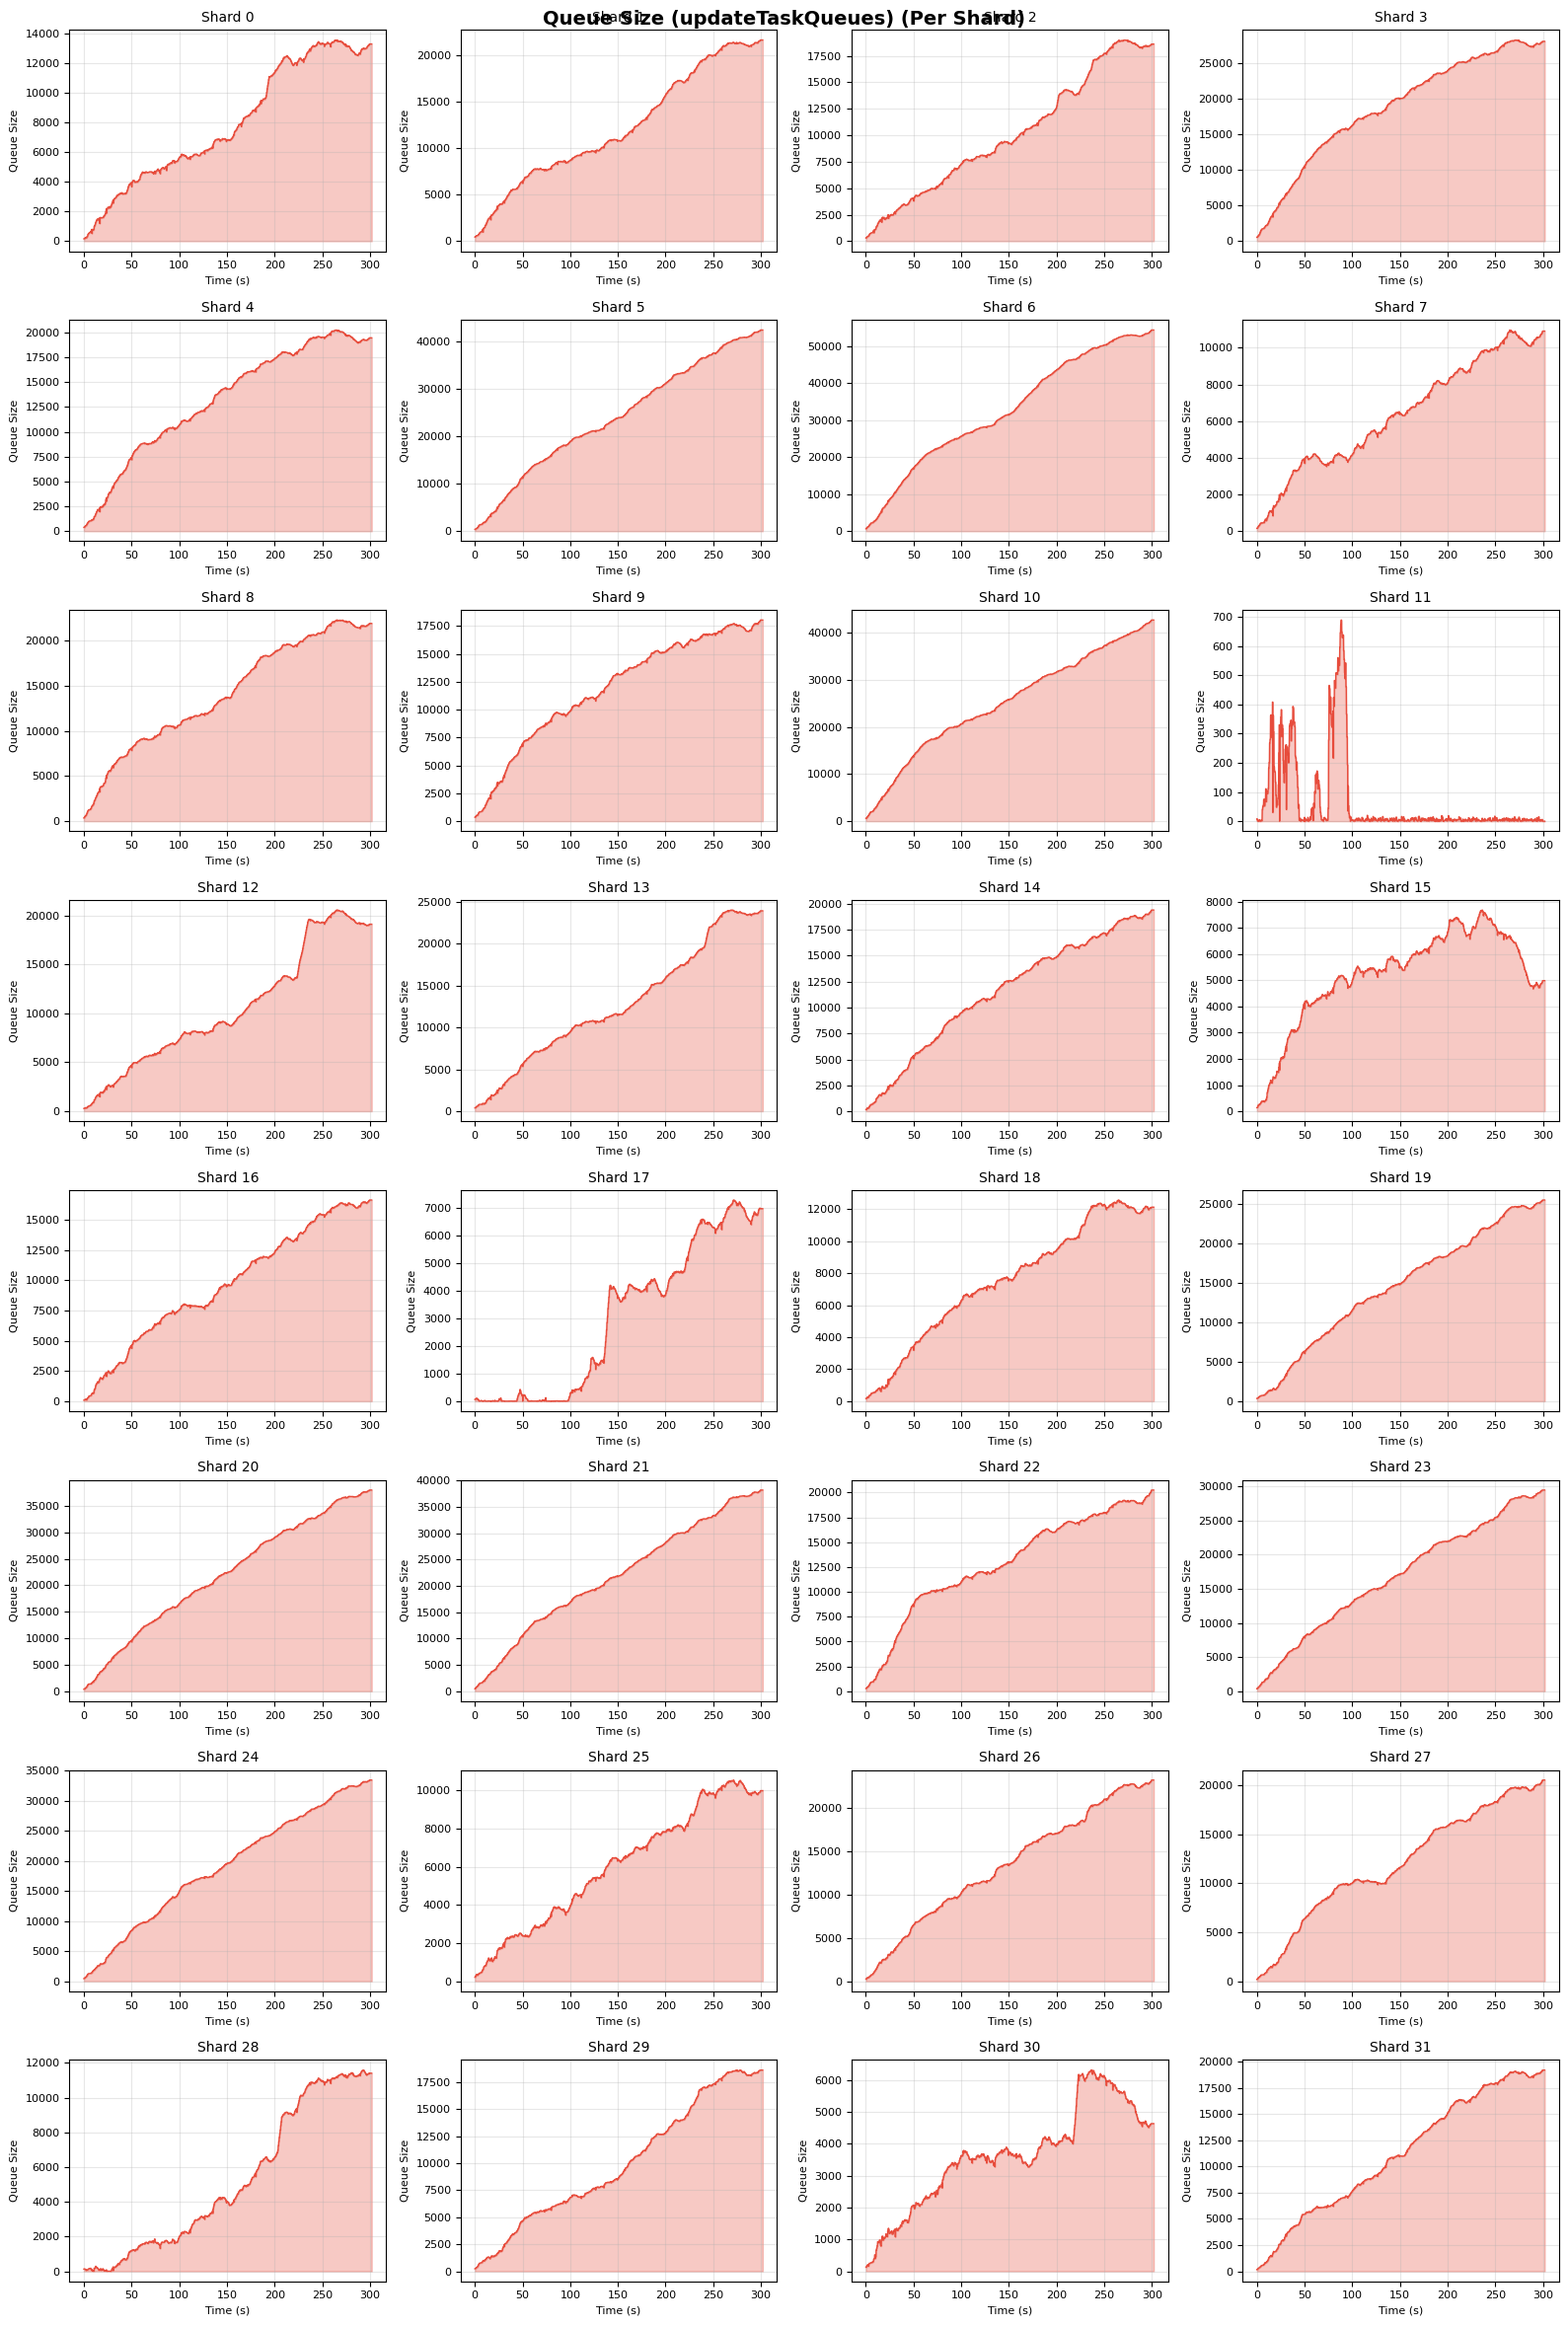

In [12]:
# Per-Shard: Queue Size
plot_per_shard(df, shard_ids, "queue_size", "Queue Size", "Queue Size (updateTaskQueues)", "#e74c3c")

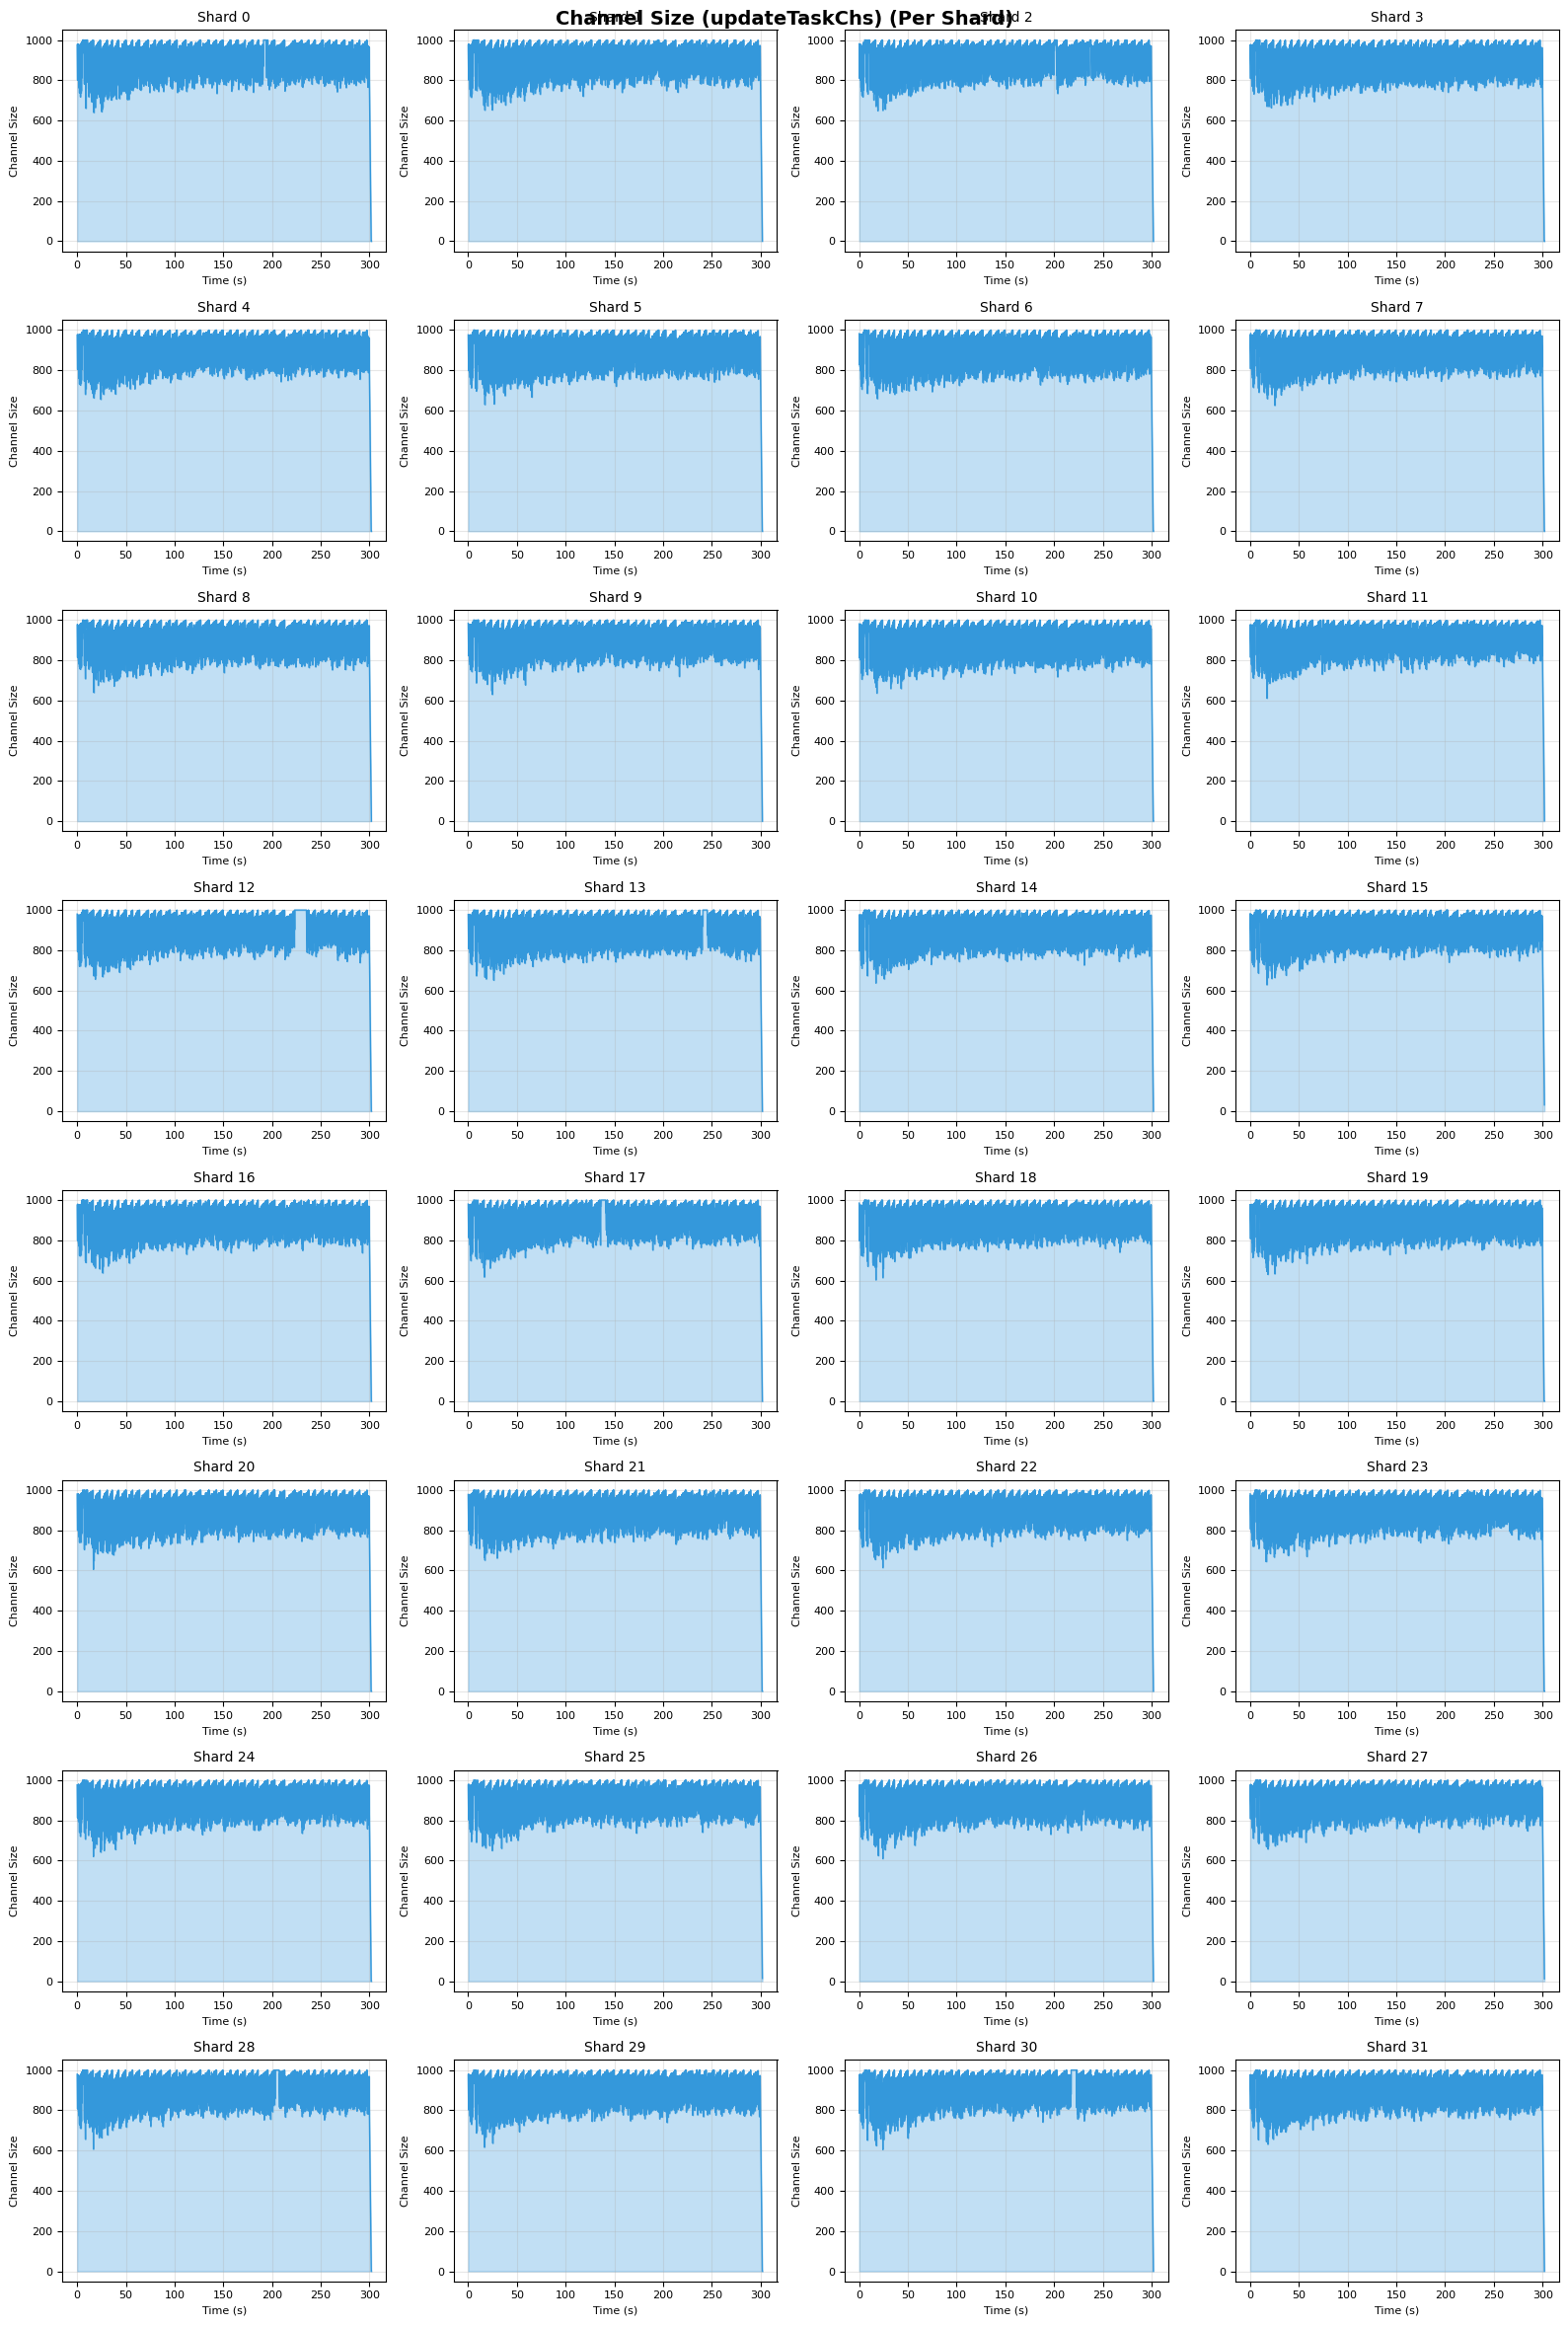

In [13]:
# Per-Shard: Channel Size
plot_per_shard(df, shard_ids, "channel_size", "Channel Size", "Channel Size (updateTaskChs)", "#3498db")

---
## Summary Statistics


In [14]:
# Aggregated Summary
print("=" * 70)
print("Aggregated Pipeline Metrics Summary")
print("=" * 70)
print(f"{'Metric':<35} {'Min':>10} {'Max':>10} {'Mean':>10}")
print("-" * 70)

for col, label in [
    ("queue_size", "Total Queue Size"),
    ("channel_size", "Total Channel Size"),
]:
    min_val = df_agg[col].min()
    max_val = df_agg[col].max()
    mean_val = df_agg[col].mean()
    print(f"{label:<35} {min_val:>10.0f} {max_val:>10.0f} {mean_val:>10.0f}")

print("=" * 70)


Aggregated Pipeline Metrics Summary
Metric                                     Min        Max       Mean
----------------------------------------------------------------------
Total Queue Size                          9080     686740     407100
Total Channel Size                          59      32000      28199


In [15]:
# Per-Shard Summary (Max Values)
print("\n" + "=" * 80)
print("Per-Shard Max Values")
print("=" * 80)
print(f"{'Shard':<8} {'Max Queue':>15} {'Max Channel':>15} {'Avg Queue':>15} {'Avg Channel':>15}")
print("-" * 80)

for shard_id in shard_ids:
    shard_df = df[df["shard_id"] == shard_id]
    if len(shard_df) > 0:
        max_queue = shard_df["queue_size"].max()
        max_channel = shard_df["channel_size"].max()
        avg_queue = shard_df["queue_size"].mean()
        avg_channel = shard_df["channel_size"].mean()
        print(f"{shard_id:<8} {max_queue:>15.0f} {max_channel:>15.0f} {avg_queue:>15.1f} {avg_channel:>15.1f}")

print("=" * 80)



Per-Shard Max Values
Shard          Max Queue     Max Channel       Avg Queue     Avg Channel
--------------------------------------------------------------------------------
0                  13538            1000          7908.1           882.0
1                  21604            1000         12264.5           883.2
2                  19003            1000         10166.9           885.6
3                  28177            1000         18837.7           875.6
4                  20260            1000         13287.2           880.4
5                  42461            1000         24216.5           875.8
6                  54300            1000         32890.7           873.3
7                  10968            1000          6405.7           880.7
8                  22286            1000         14144.4           880.3
9                  18026            1000         11904.0           883.5
10                 42652            1000         25255.5           874.8
11                   